In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, roc_curve, classification_report)
print("Environment ready")

Environment ready


In [2]:
pip install scikit-learn pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv("spotify_data_clean.csv")
df.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


In [4]:
print("Shape:", df.shape)
print(df.dtypes)
print(df.isna().sum())
df.describe()

Shape: (8582, 15)
track_id               object
track_name             object
track_number            int64
track_popularity        int64
explicit                 bool
artist_name            object
artist_popularity       int64
artist_followers        int64
artist_genres          object
album_id               object
album_name             object
album_release_date     object
album_total_tracks      int64
album_type             object
track_duration_min    float64
dtype: object
track_id                 0
track_name               0
track_number             0
track_popularity         0
explicit                 0
artist_name              3
artist_popularity        0
artist_followers         0
artist_genres         3361
album_id                 0
album_name               0
album_release_date       0
album_total_tracks       0
album_type               0
track_duration_min       0
dtype: int64


,track_number,track_popularity,artist_popularity,artist_followers,album_total_tracks,track_duration_min
count,8582.000000,8582.000000,8582.000000,8.582000e+03,8582.000000,8582.000000
mean,5.772547,52.356211,69.730016,2.403472e+07,13.789443,3.492805
std,6.052792,23.816076,19.645979,3.803180e+07,11.887131,1.057970
min,1.000000,0.000000,0.000000,0.000000e+00,1.000000,0.070000
25%,1.000000,39.000000,60.000000,4.623200e+05,6.000000,2.880000
50%,4.000000,58.000000,74.000000,6.105547e+06,13.000000,3.445000
75%,9.000000,71.000000,84.000000,2.725255e+07,17.000000,3.990000
max,102.000000,99.000000,100.000000,1.455421e+08,181.000000,13.510000


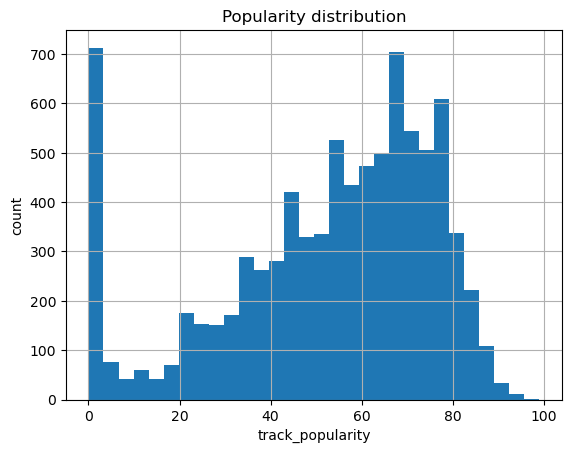

In [5]:
df['track_popularity'].describe()
df['track_popularity'].hist(bins=30)
plt.xlabel("track_popularity"); plt.ylabel("count"); plt.title("Popularity distribution")
plt.show()

In [6]:
print("Before:", df.shape)
df = df.drop_duplicates()
print("After:", df.shape)

Before: (8582, 15)
After: (8582, 15)


In [7]:
df['release_year'] = pd.to_datetime(df['album_release_date'], errors='coerce').dt.year
df['release_year'] = df['release_year'].fillna(df['release_year'].median())

In [8]:
THRESHOLD = 65
df['popular'] = (df['track_popularity'] >= THRESHOLD).astype(int)
print(df['popular'].value_counts(normalize=True))   # ~38% popular, ~62% not

popular
0    0.621067
1    0.378933
Name: proportion, dtype: float64


In [9]:
df['explicit'] = df['explicit'].astype(int)

feature_cols = ['artist_popularity', 'artist_followers', 'explicit',
                'track_duration_min', 'album_total_tracks', 'track_number',
                'release_year']

X = df[feature_cols].copy()
X = pd.concat([X, pd.get_dummies(df['album_type'], prefix='type')], axis=1)
y = df['popular']

print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (8582, 10)


,artist_popularity,artist_followers,explicit,track_duration_min,album_total_tracks,track_number,release_year,type_album,type_compilation,type_single
0,77,2812821,1,1.55,9,4,2025,True,False,False
1,64,2363438,1,3.07,1,1,2025,False,False,True
2,48,193302,1,2.55,1,1,2025,False,False,True
3,77,2813710,1,1.69,9,8,2025,True,False,False
4,48,8682,1,2.39,2,2,2025,False,False,True


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (6865, 10)  Test: (1717, 10)


In [11]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)